Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best XGB Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

Optimized Random Forest Performance
Accuracy: 0.7142857142857143
Precision: 0.5806451612903226
Recall: 0.6666666666666666
F1 Score: 0.6206896551724138

Optimized XGBoost Performance
Accuracy: 0.7272727272727273
Precision: 0.5967741935483871
Recall: 0.6851851851851852
F1 Score: 0.6379310344827587

Optimized Hybrid Model Performance
Accuracy: 0.7402597402597403
Precision: 0.609375
Recall: 0.7222222222222222
F1 Score: 0.6610169491525424


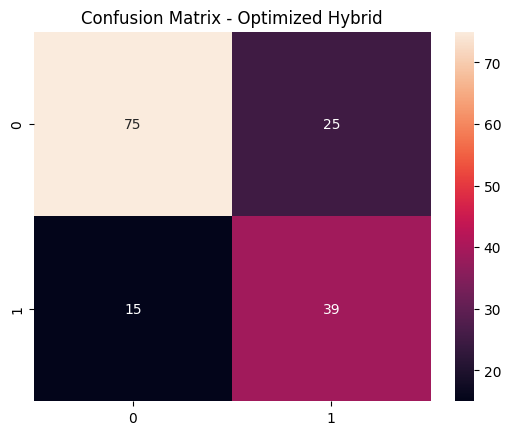

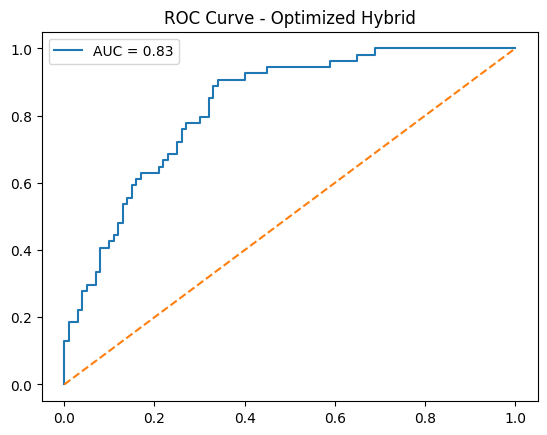

10-Fold CV Accuracy: 0.7604066985645934


In [10]:
# Optimized Hybrid Feature-Engineered Ensemble Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# 1️⃣ LOAD DATASET
data = pd.read_csv("diabetes.csv")
cols_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_replace:
    data[col] = data[col].replace(0, data[col].median())

X = data.drop("Outcome", axis=1)
y = data["Outcome"]
# 2️⃣ SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 3️⃣ FEATURE SELECTION (RFE)
lr = LogisticRegression(max_iter=1000)
rfe = RFE(lr, n_features_to_select=6)
X_selected = rfe.fit_transform(X_scaled, y)

# 4️⃣ TRAIN TEST SPLIT (IMPORTANT FIX)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# 5️⃣ APPLY SMOTE ONLY ON TRAIN DATA
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
# 6️⃣ HYPERPARAMETER TUNING - RANDOM FOREST
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print("Best RF Parameters:", rf_grid.best_params_)

# 7️⃣ HYPERPARAMETER TUNING - XGBOOST
xgb_params = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

print("Best XGB Parameters:", xgb_grid.best_params_)

# 8️⃣ HYBRID MODEL (Weighted Voting)

hybrid_model = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft',
    weights=[2, 1]
)

hybrid_model.fit(X_train, y_train)

# 9️⃣ EVALUATION

def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} Performance")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    return y_pred, y_prob, acc

rf_pred, rf_prob, rf_acc = evaluate(best_rf, "Optimized Random Forest")
xgb_pred, xgb_prob, xgb_acc = evaluate(best_xgb, "Optimized XGBoost")
hyb_pred, hyb_prob, hyb_acc = evaluate(hybrid_model, "Optimized Hybrid Model")
# 🔟 CONFUSION MATRIX
plt.figure()
cm = confusion_matrix(y_test, hyb_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Optimized Hybrid")
plt.show()

# 1️⃣1️⃣ ROC CURVE
plt.figure()
fpr, tpr, _ = roc_curve(y_test, hyb_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend()
plt.title("ROC Curve - Optimized Hybrid")
plt.show()
# 1️⃣2️⃣ STRATIFIED K-FOLD VALIDATION

skf = StratifiedKFold(n_splits=10)
cv_scores = []

for train_index, val_index in skf.split(X_selected, y):
    X_tr, X_val = X_selected[train_index], X_selected[val_index]
    y_tr, y_val = y.iloc[train_index], y.iloc[val_index]

    X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

    hybrid_model.fit(X_tr, y_tr)
    score = hybrid_model.score(X_val, y_val)
    cv_scores.append(score)

print("10-Fold CV Accuracy:", np.mean(cv_scores))